In [27]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## Definition of universe of discourse

In [13]:
error = ctrl.Antecedent(np.arange(-5, 5.1, 0.1), 'error')
trend = ctrl.Antecedent(np.arange(-2, 2.1, 0.1), 'trend')
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')
outdoor_temp = ctrl.Antecedent(np.arange(-20, 41, 1), 'outdoor_temp')
control_output = ctrl.Consequent(np.arange(-100, 101, 1), 'control_output')

## Definition of membership functions

### Temperature error

In [14]:
error['large_negative'] = fuzz.trimf(error.universe, [-5, -5, -2])
error['small_negative'] = fuzz.trimf(error.universe, [-3, -1.5, 0])
error['zero']           = fuzz.trimf(error.universe, [-0.5, 0, 0.5])
error['small_positive'] = fuzz.trimf(error.universe, [0, 1.5, 3])
error['large_positive'] = fuzz.trimf(error.universe, [2, 5, 5])

### Temperature trend

In [15]:
trend['falling_fast'] = fuzz.trimf(trend.universe, [-2, -2, -0.5])
trend['stable']       = fuzz.trimf(trend.universe, [-0.7, 0, 0.7])
trend['rising_fast']  = fuzz.trimf(trend.universe, [0.5, 2, 2])

### Humidity

In [16]:
humidity['low']    = fuzz.trapmf(humidity.universe, [0, 0, 30, 45])
humidity['optimal'] = fuzz.trimf(humidity.universe, [35, 50, 65])
humidity['high']   = fuzz.trapmf(humidity.universe, [55, 70, 100, 100])

### Outdoor temperature

In [17]:
outdoor_temp['freezing'] = fuzz.trapmf(outdoor_temp.universe, [-20, -20, -5, 5])
outdoor_temp['cold']     = fuzz.trimf(outdoor_temp.universe, [0, 12, 20])
outdoor_temp['moderate'] = fuzz.trimf(outdoor_temp.universe, [15, 22, 28])
outdoor_temp['hot']      = fuzz.smf(outdoor_temp.universe, 25, 35)

### Output control definitions

In [18]:
control_output['heavy_cooling'] = fuzz.trimf(control_output.universe, [-100, -100, -50])
control_output['light_cooling'] = fuzz.trimf(control_output.universe, [-60, -30, 0])
control_output['off']           = fuzz.trimf(control_output.universe, [-15, 0, 15])
control_output['light_heating'] = fuzz.trimf(control_output.universe, [0, 30, 60])
control_output['heavy_heating'] = fuzz.trimf(control_output.universe, [50, 100, 100])

## Rule base

In [19]:
r1 = ctrl.Rule(error['zero'] & trend['stable'], control_output['off'])
r2 = ctrl.Rule(error['large_positive'] & trend['falling_fast'], control_output['heavy_heating'])
r3 = ctrl.Rule(error['small_positive'] & trend['stable'], control_output['light_heating'])
r4 = ctrl.Rule(error['large_negative'] & trend['rising_fast'], control_output['heavy_cooling'])
r5 = ctrl.Rule(error['small_negative'] & trend['stable'], control_output['light_cooling'])

r6 = ctrl.Rule(error['small_negative'] & humidity['high'], control_output['heavy_cooling'])
r7 = ctrl.Rule(error['small_positive'] & humidity['high'], control_output['light_heating'])

r8 = ctrl.Rule(outdoor_temp['freezing'] & error['small_positive'], control_output['heavy_heating'])
r9 = ctrl.Rule(outdoor_temp['hot'] & error['zero'], control_output['light_cooling'])

## System compilation and simulation

In [20]:
hvac_control_system = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8, r9])
simulator = ctrl.ControlSystemSimulation(hvac_control_system)

## Test

In [23]:
simulator.input['error'] = 1.5
simulator.input['trend'] = -0.2
simulator.input['humidity'] = 45.0
simulator.input['outdoor_temp'] = -10.0

In [24]:
simulator.compute()

In [25]:
output_value = simulator.output['control_output']
print(f"Control Signal: {output_value:.2f}%")
if output_value > 0:
    print(f"Status - system activates heating at: {output_value:.1f}% power.")
elif output_value < 0:
    print(f"Status - system activates cooling at: {abs(output_value):.1f}% power.")
else:
    print("Status - ideal conditions. System in idle mode.")

Control Signal: 55.37%
Status - system activates heating at: 55.4% POWER.


/Users/bartoszkordek/PycharmProjects/msi1-fuzzy-temperature-control/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


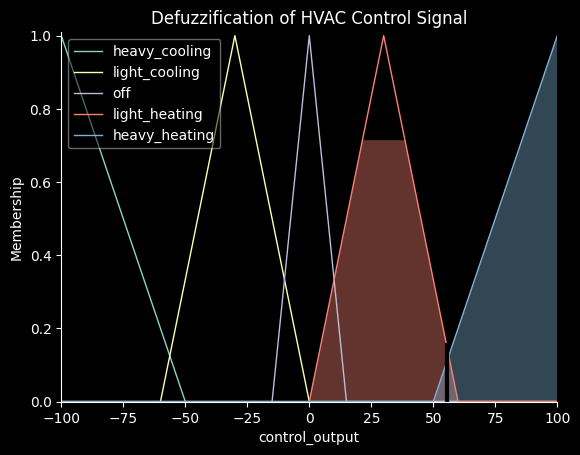

In [30]:
control_output.view(sim=simulator)
plt.title('Defuzzification of HVAC Control Signal')
plt.show()